In [1]:
#Model Development & Evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('03_data_processed/features_engineered.csv')
df.head()

,store_id,product_id,date,sales_7day_avg,sales_30day_avg,sales_lag_1,sales_lag_7,sales_trend,day_of_week,month,...,precipitation,has_rain,competitor_promotion,local_event,current_stock,reorder_point,supplier_lead_time,days_of_stock,risk_category,risk_score
0,ST001,P001,2022-01-01,4.0,4.0,0.0,0.0,0.0,5,1,...,0.04,1,False,False,40.0,12.0,7.0,9.756098,LOW_RISK,25
1,ST001,P001,2022-01-01,4.0,4.0,0.0,0.0,0.0,5,1,...,0.04,1,False,False,40.0,12.0,7.0,9.756098,LOW_RISK,25
2,ST001,P001,2022-01-01,4.0,4.0,0.0,0.0,0.0,5,1,...,0.11,1,False,False,40.0,12.0,7.0,9.756098,LOW_RISK,25
3,ST001,P001,2022-01-01,4.0,4.0,0.0,0.0,0.0,5,1,...,0.11,1,False,False,40.0,12.0,7.0,9.756098,LOW_RISK,25
4,ST001,P001,2022-01-01,4.0,4.0,0.0,0.0,0.0,5,1,...,0.01,1,False,False,40.0,12.0,7.0,9.756098,LOW_RISK,25


In [3]:
df.shape

(143889, 25)

In [4]:
df.columns.tolist()

['store_id',
 'product_id',
 'date',
 'sales_7day_avg',
 'sales_30day_avg',
 'sales_lag_1',
 'sales_lag_7',
 'sales_trend',
 'day_of_week',
 'month',
 'quarter',
 'is_weekend',
 'is_holiday',
 'days_to_holiday',
 'temperature',
 'precipitation',
 'has_rain',
 'competitor_promotion',
 'local_event',
 'current_stock',
 'reorder_point',
 'supplier_lead_time',
 'days_of_stock',
 'risk_category',
 'risk_score']

# Creating Target Variable (Business Logic)

In [5]:
def create_risk_labels(row):
    """Simple business logic to create risk categories"""
    
    # Calculate days of stock remaining
    if row['sales_7day_avg'] > 0:
        days_of_stock = row['current_stock'] / row['sales_7day_avg']
    else:
        days_of_stock = 30  # Default if no recent sales
    
    # Business rules
    if days_of_stock < 3:
        return 'STOCKOUT_RISK'
    elif days_of_stock > 20:
        return 'OVERSTOCK_RISK'  
    elif days_of_stock < 7:
        return 'MEDIUM_RISK'
    else:
        return 'LOW_RISK'

In [6]:
# Create target variable
df['risk_category'] = df.apply(create_risk_labels, axis=1)

In [7]:
print("\nRisk Category Distribution:")
print(df['risk_category'].value_counts())


Risk Category Distribution:
risk_category
OVERSTOCK_RISK    79229
LOW_RISK          30067
STOCKOUT_RISK     23287
MEDIUM_RISK       11306
Name: count, dtype: int64


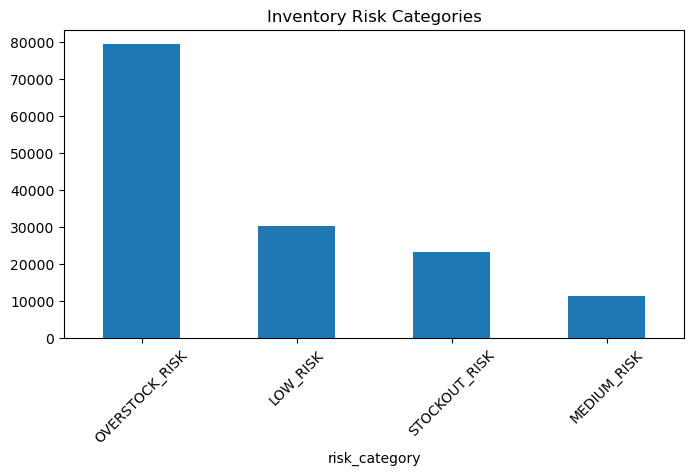

In [8]:
# Visualize target distribution
plt.figure(figsize=(8, 4))
df['risk_category'].value_counts().plot(kind='bar')
plt.title('Inventory Risk Categories')
plt.xticks(rotation=45)
plt.show()

# Prepare Features for Modeling

In [9]:
# Select important features (to avoid data leakage)
feature_columns = [
    'sales_7day_avg', 'sales_30day_avg', 'sales_trend',
    'day_of_week', 'month', 'is_weekend', 'is_holiday',
    'temperature', 'competitor_promotion', 'local_event',
    'supplier_lead_time', 'reorder_point'
    # removed 'sales_trend_7day' and 'days_since_reorder'
]


In [10]:
# Handle missing values simply
X = df[feature_columns]
y = df['risk_category']

In [11]:
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (143889, 12)
Target shape: (143889,)


# Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


Training set: (115111, 12)
Test set: (28778, 12)


# Simple Baseline Model

In [13]:
# Rule-based baseline
def baseline_prediction(row):
    """Simple rule-based model as baseline"""
    if row['sales_7day_avg'] == 0:
        return 'OVERSTOCK_RISK'
    elif row['sales_7day_avg'] > 20:
        return 'STOCKOUT_RISK'
    else:
        return 'LOW_RISK'

In [14]:
y_baseline = X_test.apply(baseline_prediction, axis=1)
baseline_f1 = f1_score(y_test, y_baseline, average='weighted')
print(f"\nBaseline F1 Score: {baseline_f1:.3f}")


Baseline F1 Score: 0.087


# Random Forest Model (Main Model)

In [15]:
# Simple Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10  # Prevent overfitting
)

In [16]:
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [17]:
# Evaluate Random Forest
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')
print(f"\nRandom Forest F1 Score: {rf_f1:.3f}")
print(f"Improvement over baseline: {rf_f1 - baseline_f1:.3f}")


Random Forest F1 Score: 0.673
Improvement over baseline: 0.586


In [18]:
# Classification report
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Classification Report:
                precision    recall  f1-score   support

      LOW_RISK       0.65      0.56      0.60      6014
   MEDIUM_RISK       0.97      0.22      0.36      2261
OVERSTOCK_RISK       0.72      0.98      0.83     15846
 STOCKOUT_RISK       0.82      0.26      0.39      4657

      accuracy                           0.71     28778
     macro avg       0.79      0.50      0.55     28778
  weighted avg       0.74      0.71      0.67     28778



# Logistic Regression (Simpler Model)

In [19]:
# Simple Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')
print(f"\nLogistic Regression F1 Score: {lr_f1:.3f}")


Logistic Regression F1 Score: 0.510


In [30]:
# Classification report
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Classification Report:
                precision    recall  f1-score   support

      LOW_RISK       0.39      0.36      0.37      6014
   MEDIUM_RISK       0.23      0.00      0.01      2261
OVERSTOCK_RISK       0.66      0.95      0.78     15846
 STOCKOUT_RISK       0.20      0.02      0.03      4657

      accuracy                           0.60     28778
     macro avg       0.37      0.33      0.30     28778
  weighted avg       0.49      0.60      0.51     28778



# Model Comparison


Model Comparison:
                 Model  F1_Score
0             Baseline  0.086726
1        Random Forest  0.673026
2  Logistic Regression  0.510395


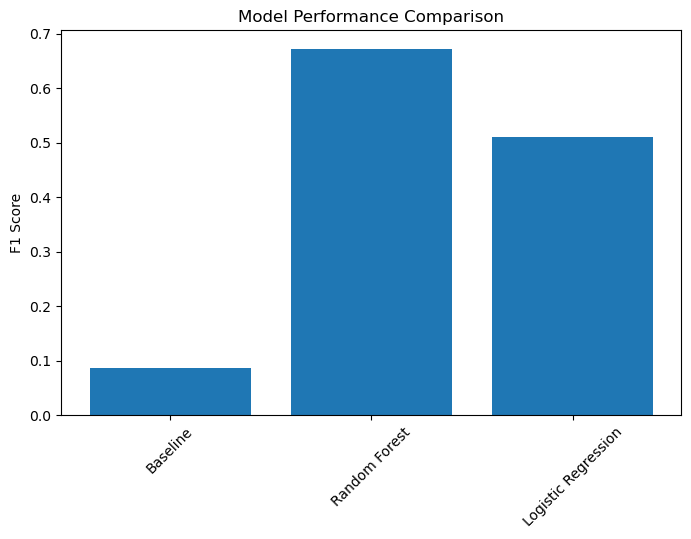

In [23]:
model_comparison = pd.DataFrame({
    'Model': ['Baseline', 'Random Forest', 'Logistic Regression'],
    'F1_Score': [baseline_f1, rf_f1, lr_f1]
})

print("\nModel Comparison:")
print(model_comparison)

# Plot comparison
plt.figure(figsize=(8, 5))
plt.bar(model_comparison['Model'], model_comparison['F1_Score'])
plt.title('Model Performance Comparison')
plt.ylabel('F1 Score')
plt.xticks(rotation=45)
plt.show()


# Feature Importance (Business Insights)

In [24]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))


Top 10 Most Important Features:
               feature  importance
11       reorder_point    0.434286
0       sales_7day_avg    0.200011
1      sales_30day_avg    0.129324
2          sales_trend    0.105271
4                month    0.060180
10  supplier_lead_time    0.046468
3          day_of_week    0.010111
7          temperature    0.007815
6           is_holiday    0.002701
5           is_weekend    0.002306


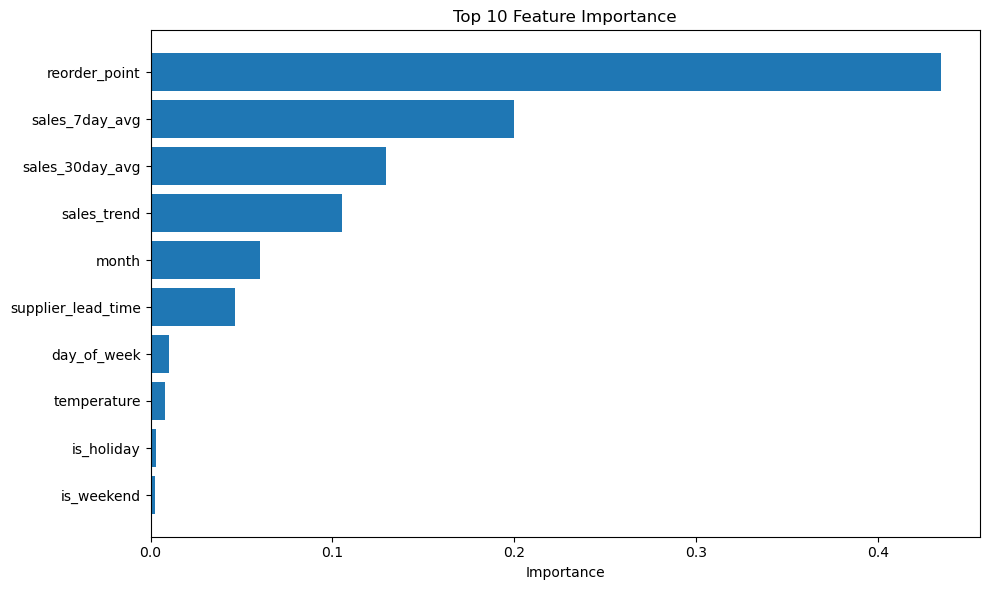

In [25]:
# Plot feature importance
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(top_features['feature'], top_features['importance'])
plt.title('Top 10 Feature Importance')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Confusion Matrix

[[ 3360     2  2600    52]
 [  747   504   816   194]
 [  326     0 15494    26]
 [  776    11  2668  1202]]


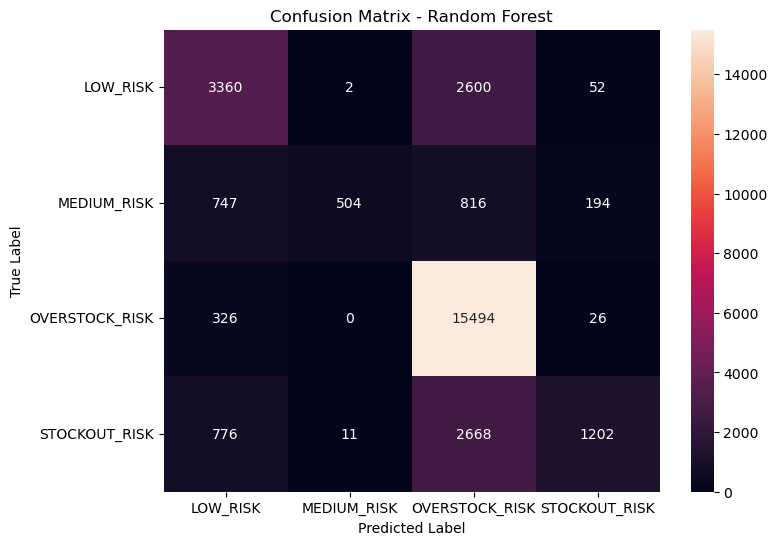

In [29]:
# Confusion matrix for Random Forest
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=rf_model.classes_, 
            yticklabels=rf_model.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Business Impact Analysis

In [30]:
# Calculate business metrics
def calculate_business_impact(y_true, y_pred):
    """Calculate business impact of predictions"""
    
    # Cost assumptions
    stockout_cost = 50  # Lost sale cost
    overstock_cost = 10  # Holding cost
    correct_prediction_value = 5  # Value of correct prediction
    
    total_cost_saved = 0
    
    for true, pred in zip(y_true, y_pred):
        if true == 'STOCKOUT_RISK' and pred == 'STOCKOUT_RISK':
            total_cost_saved += stockout_cost  # Prevented stockout
        elif true == 'OVERSTOCK_RISK' and pred == 'OVERSTOCK_RISK':
            total_cost_saved += overstock_cost  # Prevented overstock
        elif true == pred:
            total_cost_saved += correct_prediction_value  # Correct prediction
    
    return total_cost_saved

In [31]:
# Calculate business impact
baseline_impact = calculate_business_impact(y_test, y_baseline)
rf_impact = calculate_business_impact(y_test, y_pred_rf)


In [32]:
print(f"\nBusiness Impact Analysis:")
print(f"Baseline model value: ${baseline_impact}")
print(f"Random Forest value: ${rf_impact}")
print(f"Additional value from ML: ${rf_impact - baseline_impact}")


Business Impact Analysis:
Baseline model value: $42015
Random Forest value: $234360
Additional value from ML: $192345


# Make Predictions on New Data

In [39]:
def predict_inventory_risk(sales_7day, sales_30day, current_stock, 
                           day_of_week, month, temperature):
    """Make prediction for a single product"""
    
    input_data = pd.DataFrame({
        'sales_7day_avg': [sales_7day],
        'sales_30day_avg': [sales_30day],
        'sales_trend': [sales_7day - sales_30day],  # ✅ Correct name
        'day_of_week': [day_of_week],
        'month': [month],
        'is_weekend': [1 if day_of_week >= 5 else 0],
        'is_holiday': [0],
        'temperature': [temperature],
        'competitor_promotion': [0],
        'local_event': [0],
        'supplier_lead_time': [5],
        'reorder_point': [sales_7day * 2]
    })

    # Ensure feature order matches training
    input_data = input_data[feature_columns]

    prediction = rf_model.predict(input_data)[0]
    probability = rf_model.predict_proba(input_data)[0].max()
    
    return prediction, probability


In [40]:
# Test prediction
test_prediction, test_prob = predict_inventory_risk(
    sales_7day=15, sales_30day=12, current_stock=5,
    day_of_week=5, month=12, temperature=35
)

In [41]:
print(f"\nExample Prediction:")
print(f"Risk Category: {test_prediction}")
print(f"Confidence: {test_prob:.2f}")



Example Prediction:
Risk Category: STOCKOUT_RISK
Confidence: 0.51


# Save Model and Results

In [45]:
import joblib

# Save the best model
joblib.dump(rf_model, 'results/models/inventory_risk_model.pkl')
print("\nModel saved to results/models/inventory_risk_model.pkl")

# Save feature importance
feature_importance.to_csv('results/feature_importance.csv', index=False)

# Save model performance
results = pd.DataFrame({
    'Model': ['Baseline', 'Random Forest', 'Logistic Regression'],
    'F1_Score': [baseline_f1, rf_f1, lr_f1],
    'Business_Impact': [baseline_impact, rf_impact, 
                       calculate_business_impact(y_test, y_pred_lr)]
})

results.to_csv('results/model_performance.csv', index=False)



Model saved to results/models/inventory_risk_model.pkl


In [47]:
print(f" Best Model: Random Forest (F1: {rf_f1:.3f})")
print(f" Business Value: ${rf_impact - baseline_impact} additional value")
print(f" Key Insight: {feature_importance.iloc[0]['feature']} is most important factor")

 Best Model: Random Forest (F1: 0.673)
 Business Value: $192345 additional value
 Key Insight: reorder_point is most important factor
